In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
songs = pd.read_csv("spotify_songs[1].csv")
songs.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [ ]:
songs['duration_ms'] = songs["duration_ms"] / 1000
songs['duration_ms']=songs['duration_ms'].round(2)
songs = songs.rename(columns={'duration_ms': 'duration'})
songs[['track_artist','track_name', 'duration']].head()

,track_artist,track_name,duration
0,Ed Sheeran,I Don't Care (with Justin Bieber) - Loud Luxur...,194.75
1,Maroon 5,Memories - Dillon Francis Remix,162.60
2,Zara Larsson,All the Time - Don Diablo Remix,176.62
3,The Chainsmokers,Call You Mine - Keanu Silva Remix,169.09
4,Lewis Capaldi,Someone You Loved - Future Humans Remix,189.05


In [ ]:
songs_ranked=songs.sort_values(by='track_popularity', ascending=False)
songs_ranked[['track_artist','track_name','track_popularity','playlist_genre','track_album_release_date']].head()

,track_artist,track_name,track_popularity,playlist_genre,track_album_release_date
20091,Tones and I,Dance Monkey,100,latin,2019-10-17
1551,Tones and I,Dance Monkey,100,pop,2019-10-17
21468,Arizona Zervas,ROXANNE,99,r&b,2019-10-10
20092,Arizona Zervas,ROXANNE,99,latin,2019-10-10
23104,Arizona Zervas,ROXANNE,99,r&b,2019-10-10


In [ ]:
songs_ranked[['track_artist','track_name','track_popularity','playlist_genre','playlist_subgenre','track_album_release_date']].head(10)

,track_artist,track_name,track_popularity,playlist_genre,playlist_subgenre,track_album_release_date
20091,Tones and I,Dance Monkey,100,latin,latin hip hop,2019-10-17
1551,Tones and I,Dance Monkey,100,pop,post-teen pop,2019-10-17
21468,Arizona Zervas,ROXANNE,99,r&b,urban contemporary,2019-10-10
20092,Arizona Zervas,ROXANNE,99,latin,latin hip hop,2019-10-10
23104,Arizona Zervas,ROXANNE,99,r&b,hip pop,2019-10-10
30202,Arizona Zervas,ROXANNE,99,edm,pop edm,2019-10-10
9018,Roddy Ricch,The Box,98,rap,gangster rap,2019-12-06
1301,Post Malone,Circles,98,pop,post-teen pop,2019-09-06
18308,Maroon 5,Memories,98,latin,latin pop,2019-09-20
18307,The Weeknd,Blinding Lights,98,latin,latin pop,2019-11-29


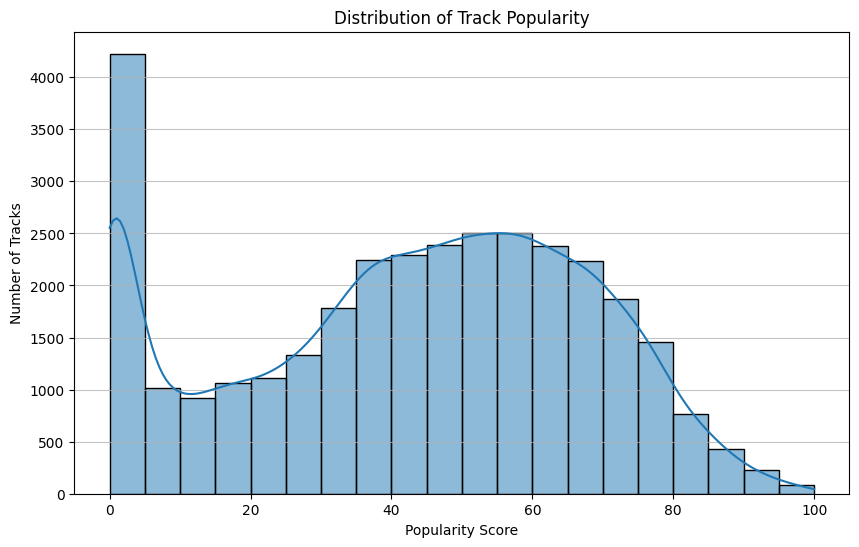

In [ ]:
# Distribution of Track Popularity
plt.figure(figsize=(10, 6))
sns.histplot(songs['track_popularity'], bins=20, kde=True)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.grid(axis='y', alpha=0.75)
plt.show()


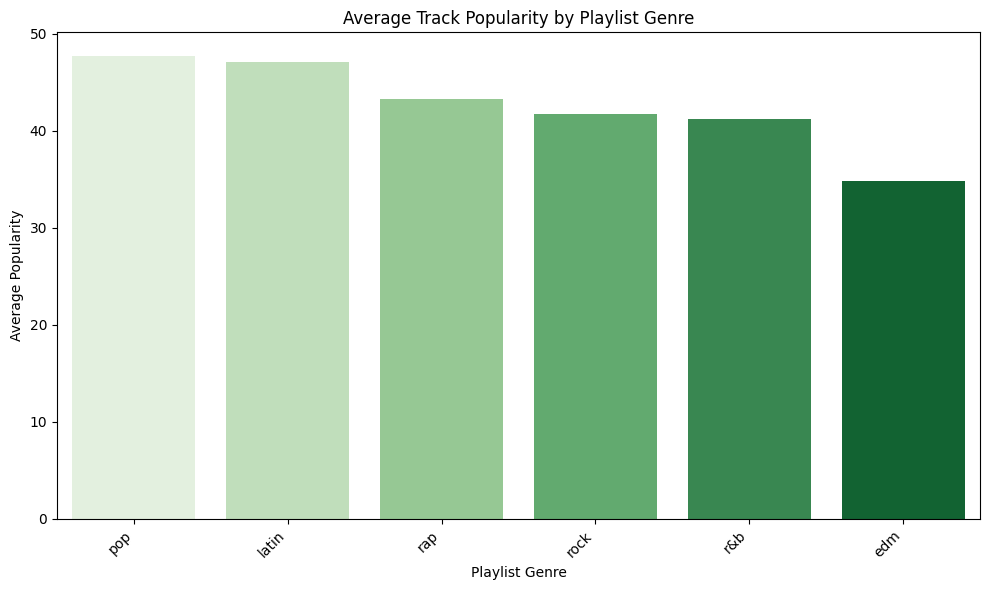

In [ ]:
# Average Popularity by Playlist Genre
plt.figure(figsize=(10, 6))
genre_popularity = songs.groupby('playlist_genre')['track_popularity'].mean().sort_values(ascending=False)
sns.barplot(x=genre_popularity.index, y=genre_popularity.values , palette='Greens
plt.title('Average Track Popularity by Playlist Genre')
plt.xlabel('Playlist Genre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

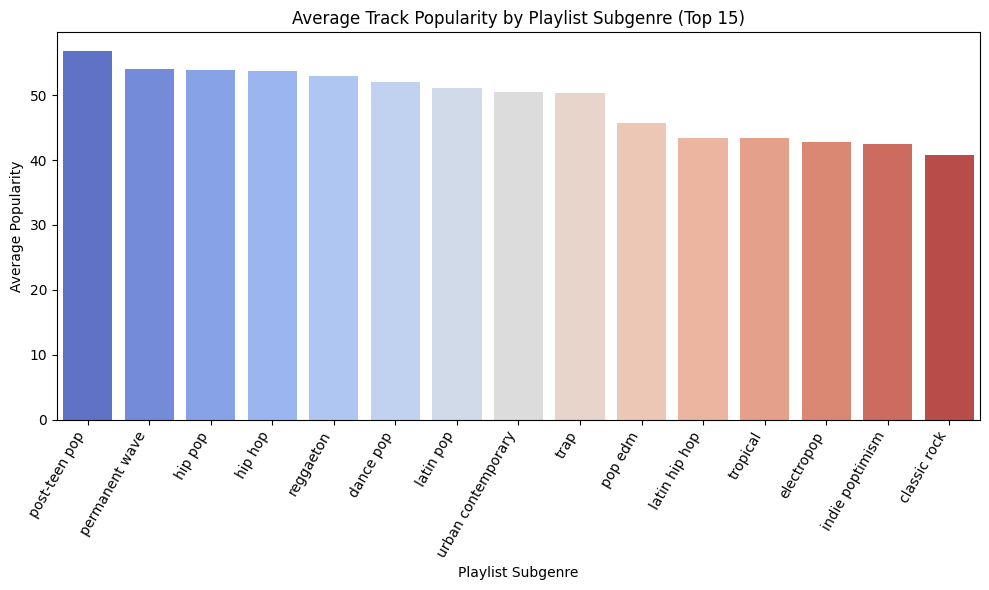

In [ ]:
# Average Popularity by Playlist Subgenre (Top 15)
plt.figure(figsize=(10, 6))
subgenre_popularity = songs.groupby('playlist_subgenre')['track_popularity'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=subgenre_popularity.index, y=subgenre_popularity.values, palette='coolwarm', hue=subgenre_popularity.index, legend=False)
plt.title('Average Track Popularity by Playlist Subgenre (Top 15)')
plt.xlabel('Playlist Subgenre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

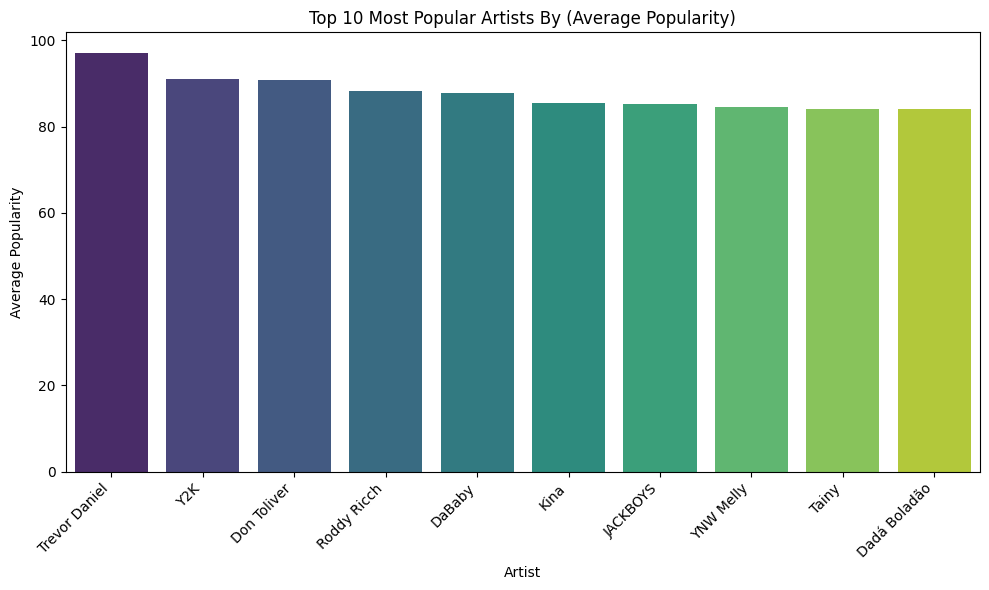

In [ ]:
# Top 10 Most Popular Artists
plt.figure(figsize=(10, 6))
top_artists = songs.groupby('track_artist')['track_popularity'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_artists.index, y=top_artists.values, palette='viridis', hue=top_artists.index, legend=False)
plt.title('Top 10 Most Popular Artists By (Average Popularity)')
plt.xlabel('Artist')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

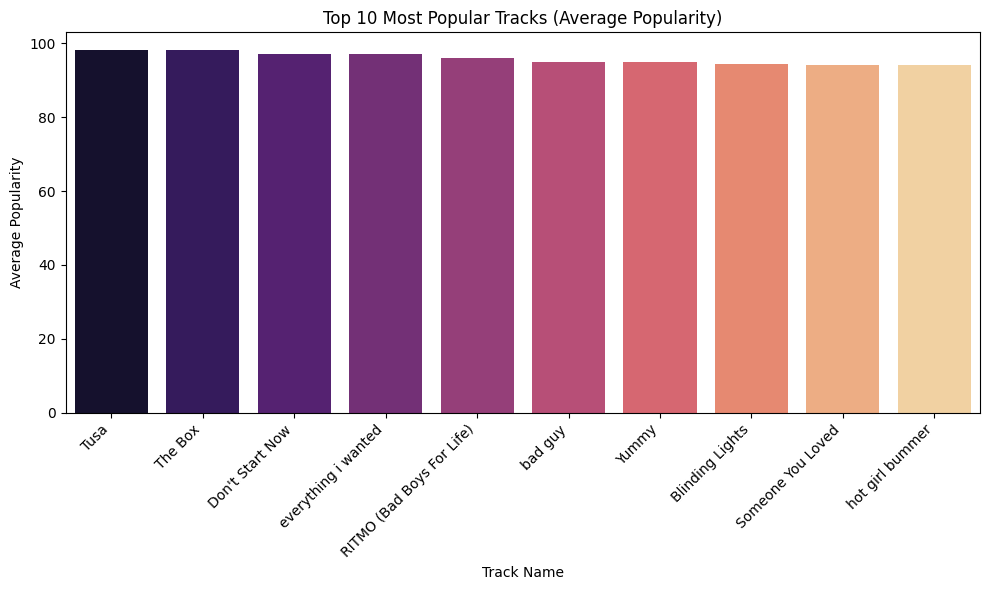

In [ ]:
# Top 10 Most Popular Tracks
plt.figure(figsize=(10, 6))
top_tracks = songs.groupby('track_name')['track_popularity'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_tracks.index, y=top_tracks.values, palette='magma', hue=top_tracks.index, legend=False)
plt.title('Top 10 Most Popular Tracks (Average Popularity)')
plt.xlabel('Track Name')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

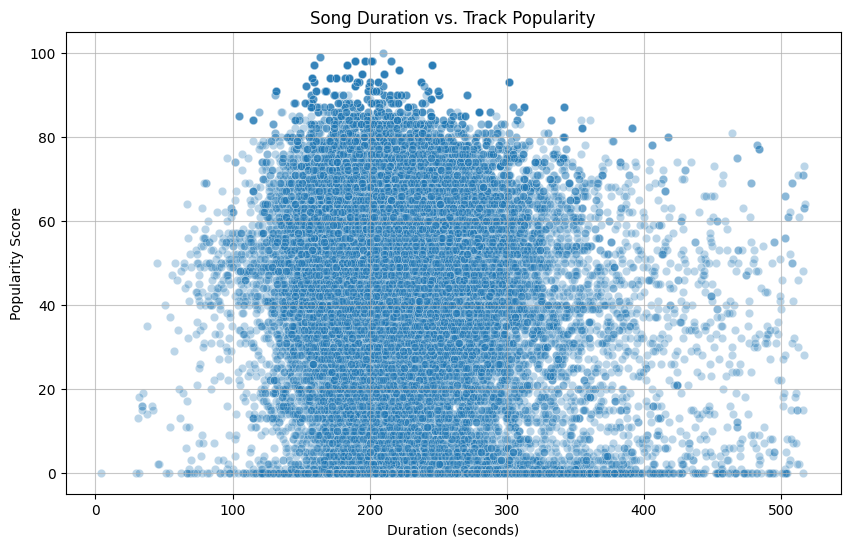

In [ ]:
# Song Duration vs. Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='track_popularity', data=songs, alpha=0.3)
plt.title('Song Duration vs. Track Popularity')
plt.xlabel('Duration (seconds)')
plt.ylabel('Popularity Score')
plt.grid(True, alpha=0.7)
plt.show()

/tmp/ipython-input-27557/2584236314.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='playlist_genre', y='track_popularity', data=songs, palette='viridis')


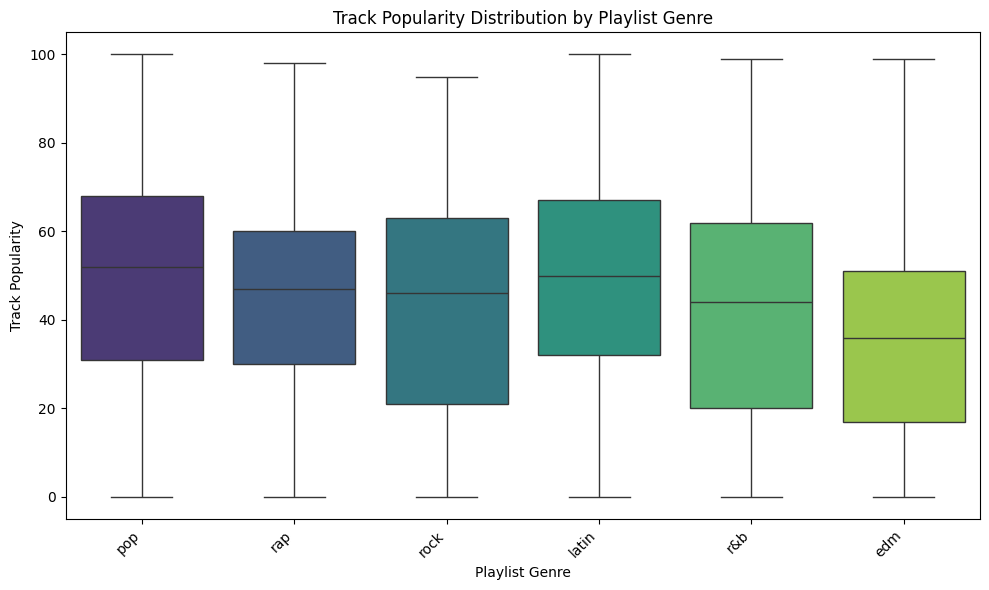

In [ ]:
# Popularity Distribution by Playlist Genre (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='playlist_genre', y='track_popularity', data=songs, palette='viridis')
plt.title('Track Popularity Distribution by Playlist Genre')
plt.xlabel('Playlist Genre')
plt.ylabel('Track Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

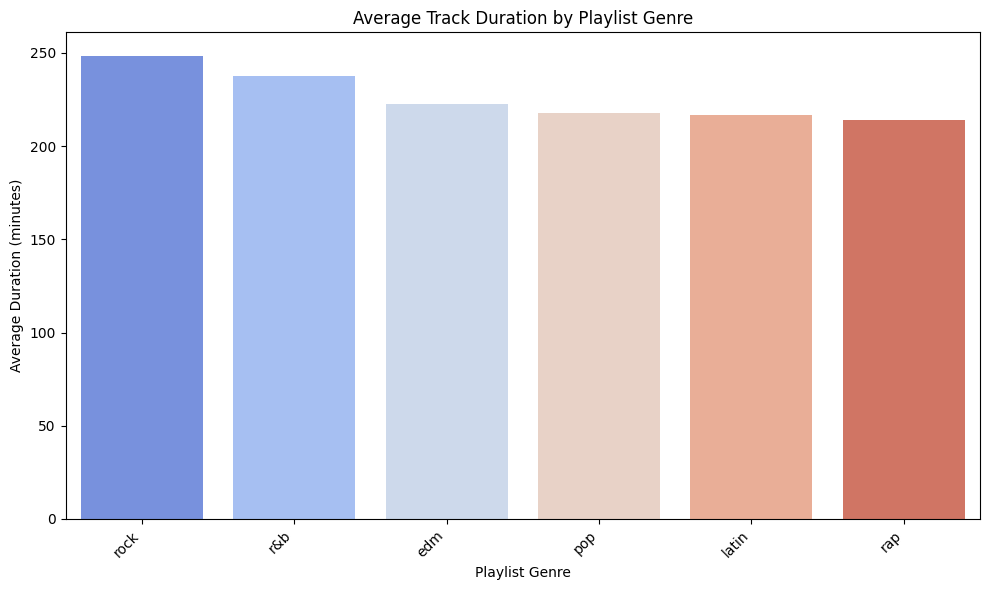

In [ ]:
# Average Track Duration by Playlist Genre
plt.figure(figsize=(10, 6))
genre_duration = songs.groupby('playlist_genre')['duration'].mean().sort_values(ascending=False)
sns.barplot(x=genre_duration.index, y=genre_duration.values, palette='coolwarm', hue=genre_duration.index, legend=False)
plt.title('Average Track Duration by Playlist Genre')
plt.xlabel('Playlist Genre')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-27557/3280896372.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='release_year', y='track_popularity', data=year_popularity, palette='viridis')


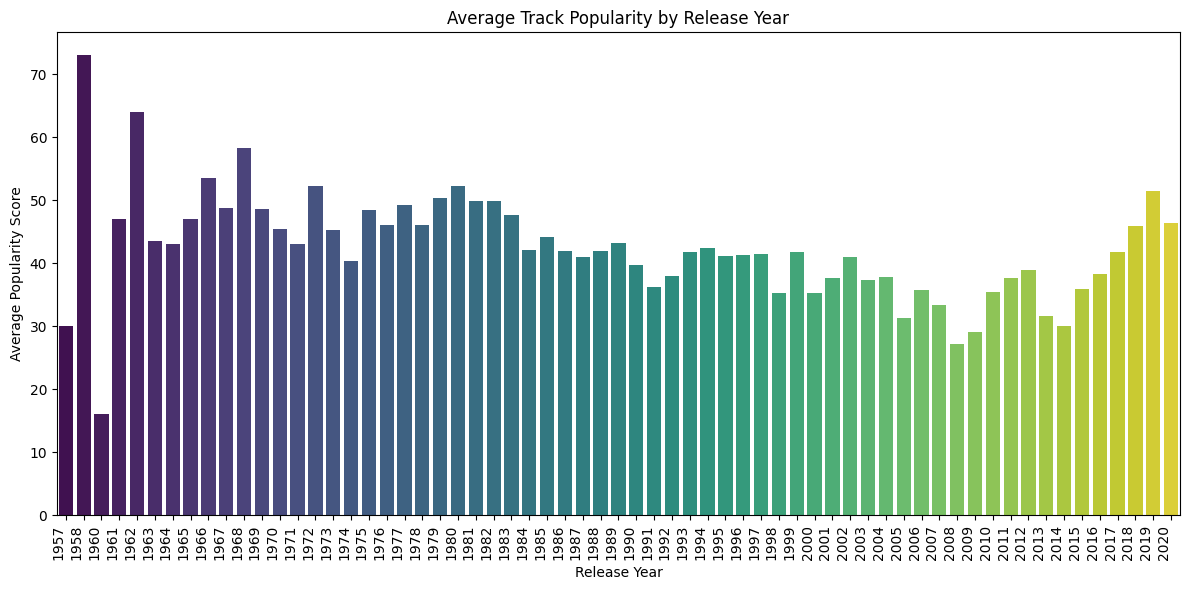

In [ ]:
songs['track_album_release_date'] = pd.to_datetime(songs['track_album_release_date'], format='mixed')
songs['release_year'] = songs['track_album_release_date'].dt.year

plt.figure(figsize=(12, 6))
year_popularity = songs.groupby('release_year')['track_popularity'].mean().reset_index()
sns.barplot(x='release_year', y='track_popularity', data=year_popularity, palette='viridis')
plt.title('Average Track Popularity by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Popularity Score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
numerical_songs = songs.select_dtypes(include=['number'])
correlation_matrix = numerical_songs.corr()
popularity_correlations = correlation_matrix['track_popularity'].sort_values(ascending=False)
print("Correlation of 'track_popularity' with other numerical features:\n", popularity_correlations)

Correlation of 'track_popularity' with other numerical features:
 track_popularity    1.000000
acousticness        0.085159
danceability        0.064748
loudness            0.057687
valence             0.033231
mode                0.010637
speechiness         0.006819
key                -0.000650
tempo              -0.005378
liveness           -0.054584
energy             -0.109112
duration           -0.143682
instrumentalness   -0.149872
Name: track_popularity, dtype: float64


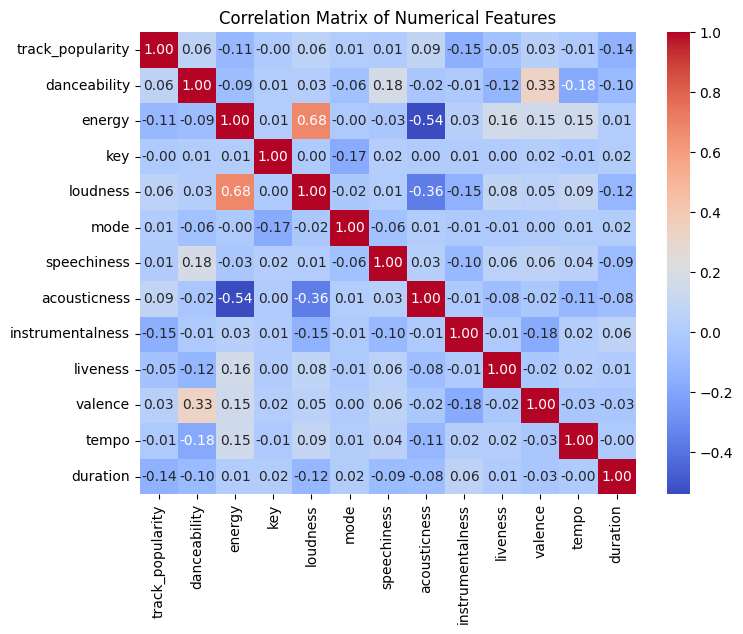

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
'''Data Analysis Key Findings

Strong Positive Correlation: A very strong positive correlation (0.68) was observed between energy and loudness, suggesting that more energetic songs tend to be louder.

Strong Negative Correlation: A moderate negative correlation (-0.54) exists between energy and acousticness, indicating that highly acoustic songs generally have lower energy. Similarly, loudness and acousticness showed a negative correlation (-0.36).

Moderate Positive Correlations: danceability and valence exhibited a moderate positive correlation (0.33), implying that more danceable songs often have a positive mood. energy and tempo also showed a positive correlation (0.15).

Correlations with track_popularity:

Weak negative correlations were found between instrumentalness and track_popularity (-0.15), and duration and track_popularity (-0.14), suggesting that highly instrumental or longer songs might be slightly less popular.
Most other features, including key, mode, speechiness, liveness, and tempo, showed very weak or negligible linear correlations with track_popularity.'''